In [1]:
# 필요한 도구 설치
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rc

# 한글 깨짐 방지
rc('font', family='Malgun Gothic')
plt.rcParams['axes.unicode_minus'] = False

# 1 데이터 전처리

In [2]:
# 파이썬에서 읽기 쉽게 전처리
file_name = "최종 엑셀 가공본.xlsx"
monthly_bonghap = pd.read_excel(file_name)

# 날짜 데이터 변환 ( 주기 데이터 -> 월 별 데이터로 전환 )
def make_date_from_week(row):
    start_year = int(str(row['year']).split('~')[0])
    week = int(row['week'])
    if week >= 30: year = start_year
    else: year = start_year + 1
    try: return pd.to_datetime(f'{year}-{week}-1', format='%Y-%W-%w')
    except: return pd.NaT

# 결측값 처리
monthly_bonghap['date'] = monthly_bonghap.apply(make_date_from_week, axis=1)
monthly_bonghap = monthly_bonghap.dropna(subset=['date'])

# 월 별로 전환한 데이터를 합산
try:
    monthly_final = monthly_bonghap.set_index('date').resample('ME')['value'].sum().reset_index()
except ValueError:
    monthly_final = monthly_bonghap.set_index('date').resample('M')['value'].sum().reset_index()
monthly_final.columns = ['month', 'value']

# 2 원본 데이터 ADF 검정

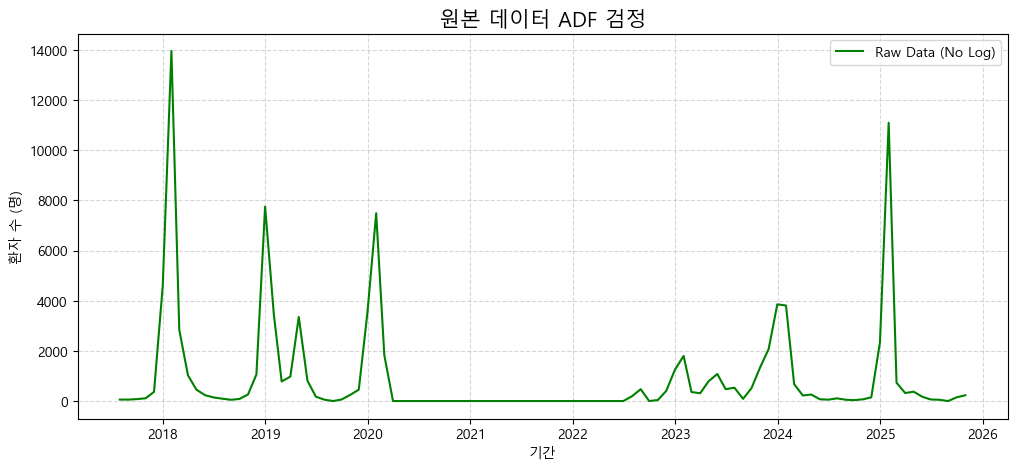

ADF Statistic: -1.9037
p-value: 0.33032


In [3]:
# 원본 데이터 ADF 검정 
from statsmodels.tsa.stattools import adfuller
target_data = monthly_final['value']

plt.figure(figsize=(12, 5))
plt.plot(monthly_final['month'], target_data, color='green', label='Raw Data (No Log)')
plt.title("원본 데이터 ADF 검정", fontsize=15)
plt.xlabel('기간')
plt.ylabel('환자 수 (명)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.show()

# 결측값 제거 후 ADF 검정 , p값 출력
result = adfuller(target_data.dropna())
print(f"ADF Statistic: {result[0]:.4f}")
print(f"p-value: {result[1]:.5f}")

# 0.05 이상이므로 로그 변환!

# 원본 데이터의 ADF 검정 결과, p값이 0.05보다 크므로 분산을 안정화하기 위해 로그 변환을 수행

# 3 로그 변환

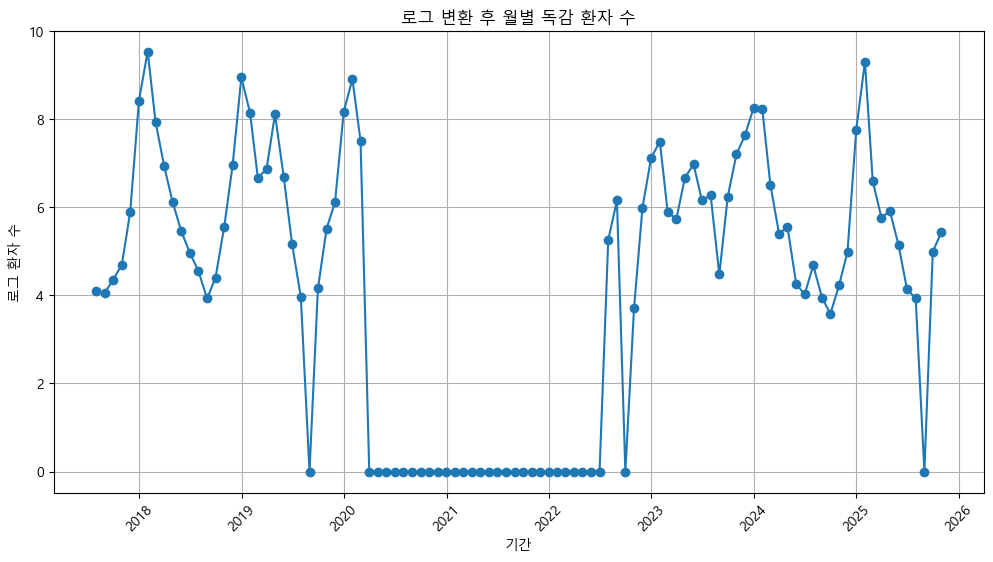

In [4]:
# 원본 데이터에 로그 변환
monthly_final['log_value'] = np.log1p(monthly_final['value'])

plt.figure(figsize=(12, 6))
plt.plot(monthly_final["month"], monthly_final["log_value"], marker="o")

plt.title("로그 변환 후 월별 독감 환자 수")
plt.xlabel("기간")
plt.ylabel("로그 환자 수")
plt.grid(True)
plt.xticks(rotation=45)
plt.show()

# 로그 변환 후에도 시각적으로 계절성이 남아있었기 때문에, 계절 차분을 수행

# 4 계절 차분

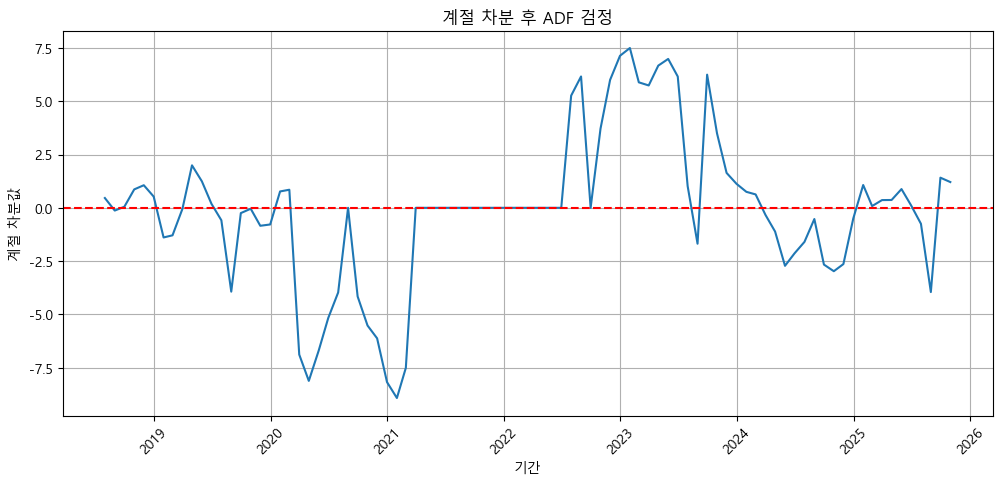

ADF Statistic: -1.7360
p-value: 0.41266


In [5]:
# 계절 차분 수행
from statsmodels.tsa.stattools import adfuller

# 계절 차분 수행 (현재 달의 로그값에서 12개월 전 데이터를 빼줌)
monthly_final['log_diff_12'] = monthly_final['log_value'].diff(12)

plt.figure(figsize=(12, 5))
plt.plot(monthly_final['month'], monthly_final['log_diff_12'])
plt.title("계절 차분 후 ADF 검정")
plt.axhline(y=0, color='r', linestyle='--') # 0점 기준선
plt.xlabel("기간")
plt.ylabel("계절 차분값")
plt.grid(True)
plt.xticks(rotation=45)
plt.show()

# 계절 차분 후 ADF 검정
target_data = monthly_final['log_diff_12'].dropna()
result = adfuller(target_data)

print(f"ADF Statistic: {result[0]:.4f}")
print(f"p-value: {result[1]:.5f}")

# 계절 차분을 수행한 뒤, 여전히 뚜렷한 추세가 남아있으며 p값이 여전히 0.05 이상이므로 추가적으로 일반 차분을 수행

# 5 계절 차분 + 일반 차분 (d=1)

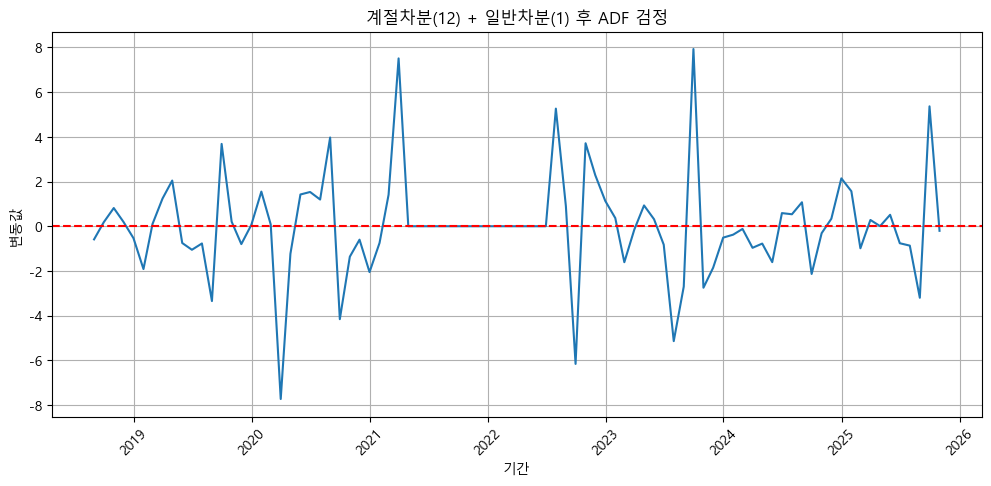

ADF Statistic: -2.8559
p-value: 0.05072


In [6]:
# 계절 차분 + 일반 차분 (d=1) 수행
from statsmodels.tsa.stattools import adfuller

# 계절 차분된 값에서 전 달의 계절 차분된 값을 빼줌
monthly_final['log_diff_12_1'] = monthly_final['log_diff_12'].diff(1)

plt.figure(figsize=(12, 5))
plt.plot(monthly_final['month'], monthly_final['log_diff_12_1'])
plt.title("계절차분(12) + 일반차분(1) 후 ADF 검정")
plt.axhline(y=0, color='r', linestyle='--') # 0점 기준선
plt.xlabel("기간")
plt.ylabel("변동값")
plt.grid(True)
plt.xticks(rotation=45)
plt.show()

# 계절 차분 + 일반 차분 (d=1) ADF 검정
target_data = monthly_final['log_diff_12_1'].dropna()
result = adfuller(target_data)

print(f"ADF Statistic: {result[0]:.4f}")
print(f"p-value: {result[1]:.5f}")

# 계절 차분과 일반 차분 후, p값이 0.05를 미세하게 넘어 일반 차분 (d=2) 도 수행해 본 결과, 과차분 현상이 일어나 계절 차분과 일반 차분 (d=1) 까지 수행

# 6 계절 차분 + 일반 차분 (d=1) 후 ACF / PACF

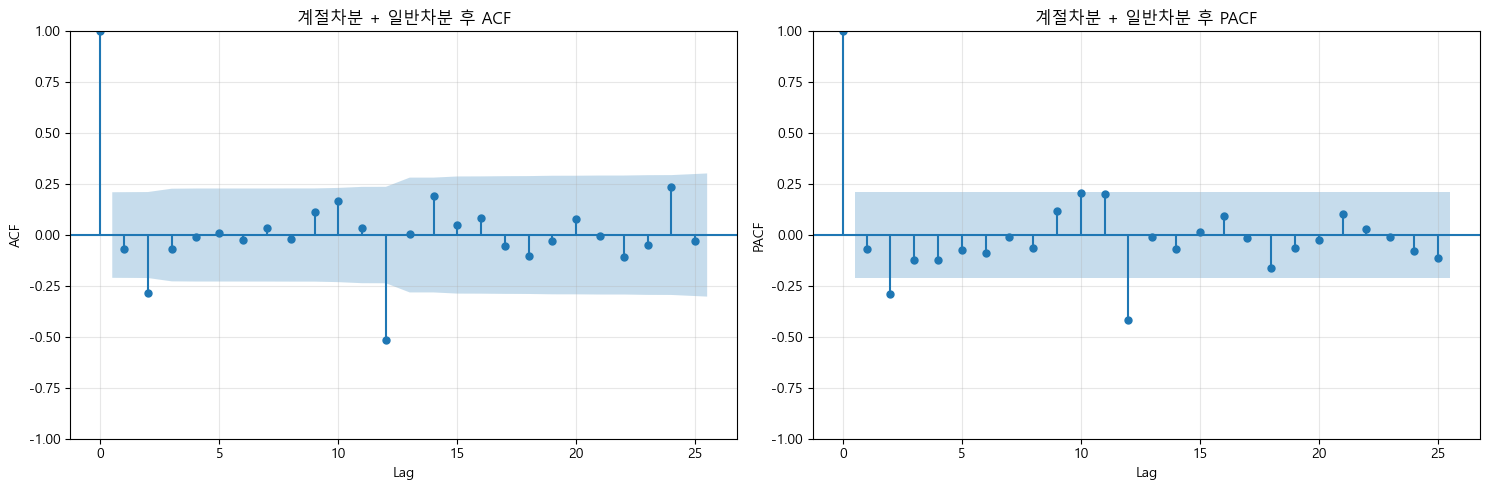

In [7]:
# 계절 차분 + 일반 차분 (d=1) 후 ACF/PACF 
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
target_data = monthly_final['log_diff_12_1'].dropna()
fig, ax = plt.subplots(1, 2, figsize=(15, 5))

# 계절 차분 + 일반 차분 (d=1) 후 ACF
plot_acf(target_data, lags=25, ax=ax[0])
ax[0].set_title("계절차분 + 일반차분 후 ACF")
ax[0].set_xlabel("Lag")
ax[0].set_ylabel("ACF")
ax[0].grid(True, alpha=0.3)

# 계절 차분 + 일반 차분 (d=1) 후 PACF
plot_pacf(target_data, lags=25, ax=ax[1], method='ywm')
ax[1].set_title("계절차분 + 일반차분 후 PACF")
ax[1].set_xlabel("Lag")
ax[1].set_ylabel("PACF")
ax[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 계절 차분 + 일반 차분을 수행한 뒤 ACF / PACF 를 확인해 본 결과, 계절성 확인

# 7 SARIMA (0,1,0)(1,1,1,12)

In [8]:
# SARIMA (0,1,0)(1,1,1,12)
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.stats.diagnostic import acorr_ljungbox

model_v2 = SARIMAX(monthly_final['log_value'],
                   order=(0, 1, 0),              
                   seasonal_order=(1, 1, 1, 12), 
                   enforce_stationarity=False,
                   enforce_invertibility=False)

results_v2 = model_v2.fit(disp=False)

print(results_v2.summary())

                                      SARIMAX Results                                       
Dep. Variable:                            log_value   No. Observations:                  100
Model:             SARIMAX(0, 1, 0)x(1, 1, [1], 12)   Log Likelihood                -156.333
Date:                              Mon, 13 Apr 2026   AIC                            318.667
Time:                                      05:56:53   BIC                            325.579
Sample:                                           0   HQIC                           321.424
                                              - 100                                         
Covariance Type:                                opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.S.L12      -0.8252      0.094     -8.791      0.000      -1.009      -0.641
ma.S.L12       0.45

# SARIMA (0,1,0)(1,1,1,12) 의 결과값이 모두 유의함을 확인

# 8 SARIMA (0,1,0)(1,1,1,12) 의 잔차 시계열

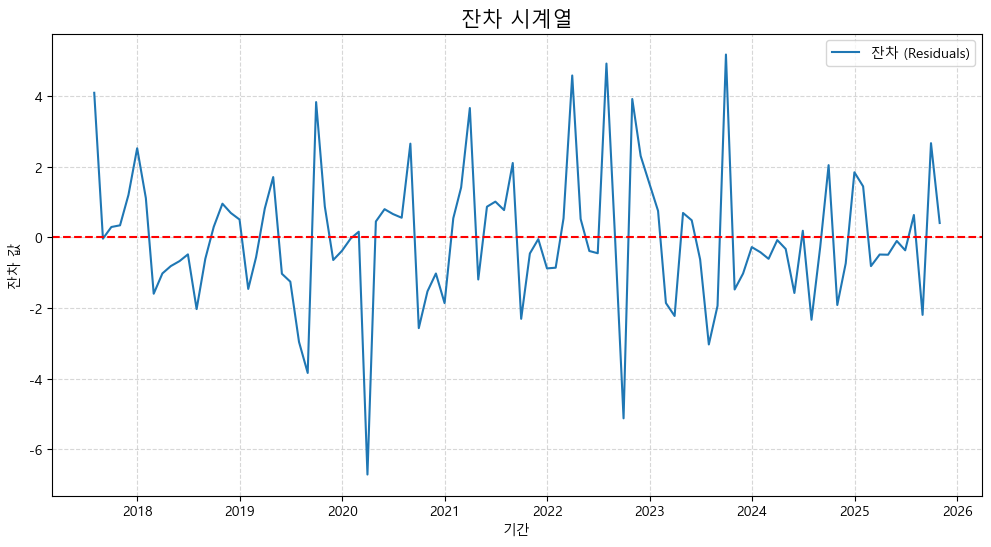

In [9]:
# 잔차 시계열
residuals = results_v2.resid

plt.figure(figsize=(12, 6))
plt.plot(monthly_final['month'], residuals, label='잔차 (Residuals)')
plt.axhline(y=0, color='r', linestyle='--', linewidth=1.5)

plt.title('잔차 시계열', fontsize=15)
plt.xlabel('기간')
plt.ylabel('잔차 값')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.show()

# SARIMA (0,1,0)(1,1,1,12) 의 잔차가 빨간 선인 0을 중심으로 불규칙하게 퍼져 있는 것을 확인

# 9 SARIMA (0,1,0)(1,1,1,12) 의 잔차 ACF / PACF

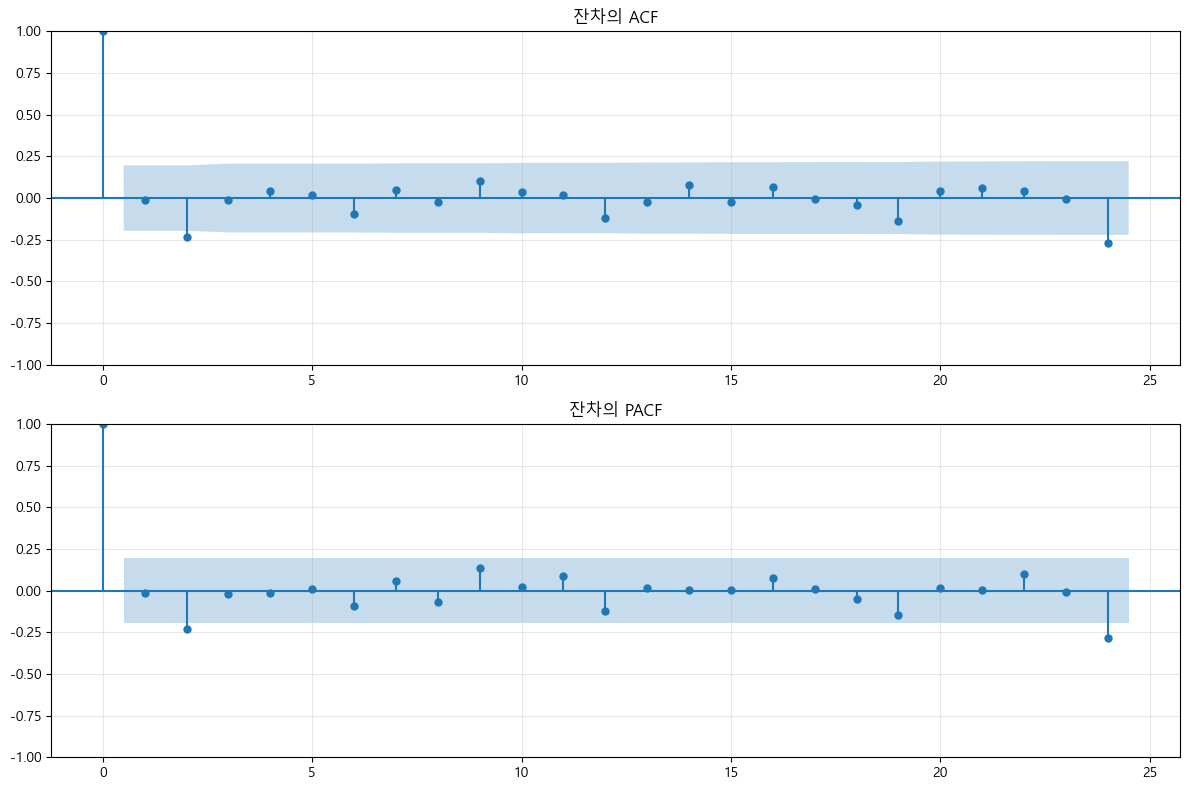

In [10]:
# 잔차의 ACF/PACF
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
residuals = results_v2.resid

# 잔차의 ACF
plt.figure(figsize=(12, 8))
plt.subplot(2, 1, 1)
plot_acf(residuals, lags=24, ax=plt.gca(), title="잔차의 ACF")
plt.grid(True, alpha=0.3)

# 잔차의 PACF
plt.subplot(2, 1, 2)
plot_pacf(residuals, lags=24, ax=plt.gca(), title="잔차의 PACF")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 시각적으로, 대부분의 잔차가 파란색 음영 안에 위치

# 10 SARIMA (0,1,0)(1,1,1,12) 의 잔차 포트맨토 검정

In [11]:
# 잔차 포트맨토 검정
print("\n=== 잔차 포트맨토 검정 (Ljung-Box) ===")
lb_result = acorr_ljungbox(results_v2.resid, lags=[12], return_df=True)

# 잔차의 통계량, p값 출력
print(lb_result)


=== 잔차 포트맨토 검정 (Ljung-Box) ===
      lb_stat  lb_pvalue
12  10.139673   0.603709


# 포트맨토 검정 결과, 포트맨토 값이 0.60으로 수치적으로도 확인

# 11 2027년도 독감 환자 수 예측

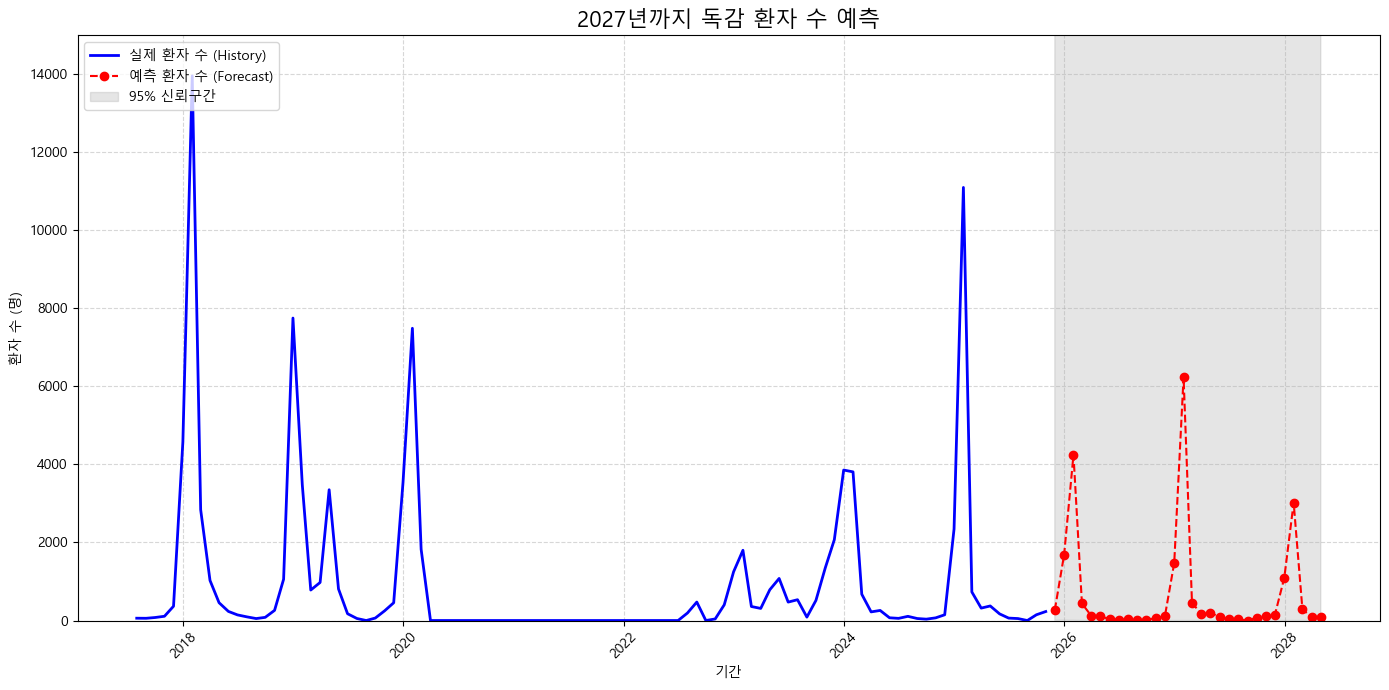

In [12]:
# 2027년도 독감 환자 수 예측
forecast = results_v2.get_forecast(steps=30)
pred_log = forecast.predicted_mean
conf_int_log = forecast.conf_int()

# 로그를 씌웠던 데이터 -> 실제 데이터로 되돌리기
pred_value   = np.expm1(pred_log)
lower_limits = np.expm1(conf_int_log.iloc[:, 0])
upper_limits = np.expm1(conf_int_log.iloc[:, 1])

# 환자 수는 음수가 될 수 없으므로, 음수는 0으로 보정
pred_value[pred_value < 0] = 0
lower_limits[lower_limits < 0] = 0
upper_limits[upper_limits < 0] = 0


plt.figure(figsize=(14, 7))
last_date = monthly_final["month"].iloc[-1]
prediction_dates = pd.date_range(start=last_date, periods=31, freq="ME")[1:]
plt.plot(monthly_final["month"], np.expm1(monthly_final["log_value"]),
         label="실제 환자 수 (History)", color="blue", linewidth=2)
plt.plot(prediction_dates, pred_value,
         label="예측 환자 수 (Forecast)", color="red", linestyle="--", marker="o")
plt.fill_between(prediction_dates, lower_limits, upper_limits,
                 color="gray", alpha=0.2, label="95% 신뢰구간")

# 그래프 진폭의 왜곡을 방지하기 위해 Y축의 범위를 0 ~ 15000명으로 설정 
plt.ylim(0, 15000)

plt.title("2027년까지 독감 환자 수 예측", fontsize=16)
plt.xlabel("기간")
plt.ylabel("환자 수 (명)")
plt.legend(loc="upper left")
plt.grid(True, linestyle="--", alpha=0.5)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 다른 모델보다 SARIMA(0,1,0)(1,1,1,12) 모델이 가장 예측에 적합하였다. 겨울마다 환자가 늘어나는 독감 특유의 계절성을 표현하여 미래를 그렸고, 단순히 지난 달 값을 따라가는 것이 아닌 여름에는 0에 수렴하고, 겨울에는 약 6,000명 까지 오르는 결과값을 만들었다는 점에서 데이터의 구조를 잘 이해하였다고 판단하였다.

# 12 2027년도 독감 환자 수 예측값의 RMSE / MAE

In [13]:
# 예측값의 RMSE/MAE
from sklearn.metrics import mean_squared_error, mean_absolute_error

# 환자 수가 0보다 큰 값만 골라 예측 로그 값을 실제 값으로 변환
mask   = monthly_final['value'] > 0
actual = monthly_final.loc[mask, 'value']
fitted = np.expm1(results_v2.fittedvalues[mask])

# 양쪽에 존재하는 공통 날짜 찾기
common_idx = actual.index.intersection(fitted.index)
actual = actual.loc[common_idx]
fitted = fitted.loc[common_idx]

rmse = np.sqrt(mean_squared_error(actual, fitted))
mae  = mean_absolute_error(actual, fitted)
print(f"RMSE : {rmse:,.0f}명")
print(f"MAE  : {mae:,.0f}명")

RMSE : 3,022명
MAE  : 1,436명


# 독감은 계절성이 강해 여름과 겨울의 편차가 크다. 겨울에는 1만명 이상의 독감 환자가 발생하기도 하였는데, 겨울 데이터 (11월~2월)의 오차가 RMSE를 높이는 주요 원인으로 판단하였다.